In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/All-seasons.csv")
print(df.shape)
df.head()

(70896, 4)


,Season,Episode,Character,Line
0,10,1,Stan,"You guys, you guys! Chef is going away. \n"
1,10,1,Kyle,Going away? For how long?\n
2,10,1,Stan,Forever.\n
3,10,1,Chef,I'm sorry boys.\n
4,10,1,Stan,"Chef said he's been bored, so he joining a gro..."


In [2]:
character_counts = df["Character"].value_counts()
print(f"Total unique characters: {len(character_counts)}")
print("\nTop 10 characters:")
print(character_counts.head(10))

Total unique characters: 3950

Top 10 characters:
Character
Cartman         9774
Stan            7680
Kyle            7099
Butters         2602
Randy           2467
Mr. Garrison    1002
Chef             917
Kenny            881
Sharon           862
Mr. Mackey       633
Name: count, dtype: int64


In [3]:
top_6 = character_counts.head(6).index.tolist()
print("Selected characters:", top_6)

df = df[df["Character"].isin(top_6)]
print(f"\nDataset size after filtering: {len(df)}")
print("\nLines per character:")
print(df["Character"].value_counts())

Selected characters: ['Cartman', 'Stan', 'Kyle', 'Butters', 'Randy', 'Mr. Garrison']

Dataset size after filtering: 30624

Lines per character:
Character
Cartman         9774
Stan            7680
Kyle            7099
Butters         2602
Randy           2467
Mr. Garrison    1002
Name: count, dtype: int64


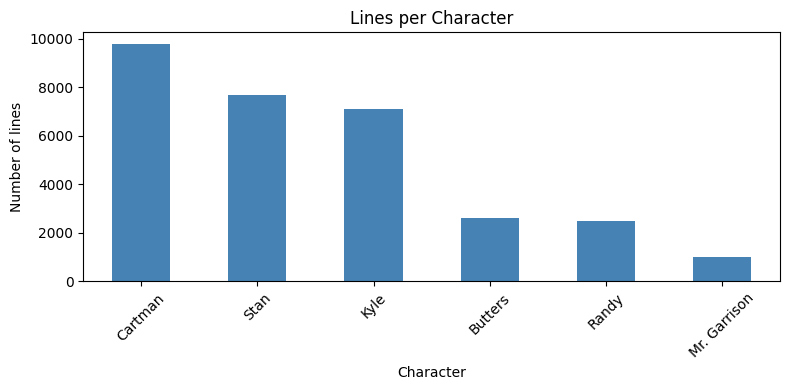

In [4]:
plt.figure(figsize=(8, 4))
df["Character"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Lines per Character")
plt.xlabel("Character")
plt.ylabel("Number of lines")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/class_distribution.png")
plt.show()

In [5]:
df = df.copy()
df["Line"] = df["Line"].str.replace("\n", " ").str.strip()
df["Line"] = df["Line"].str.replace(r"\(.*?\)", "", regex=True).str.strip()

# Remove very short lines (less than 3 words)
df = df[df["Line"].str.split().str.len() >= 3]

print(f"Dataset size after cleaning: {len(df)}")
print("\nLines per character after cleaning:")
print(df["Character"].value_counts())

Dataset size after cleaning: 25681

Lines per character after cleaning:
Character
Cartman         8483
Stan            6247
Kyle            5765
Randy           2157
Butters         2112
Mr. Garrison     917
Name: count, dtype: int64


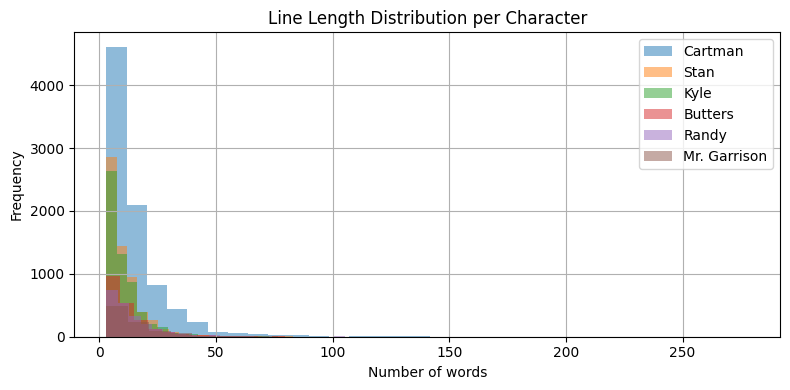

Character
Butters         13.6
Cartman         15.1
Kyle            10.7
Mr. Garrison    16.3
Randy           14.2
Stan            10.7
Name: line_length, dtype: float64


In [6]:
df["line_length"] = df["Line"].str.split().str.len()

plt.figure(figsize=(8, 4))
for character in top_6:
    subset = df[df["Character"] == character]["line_length"]
    subset.hist(bins=30, alpha=0.5, label=character)
plt.title("Line Length Distribution per Character")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/line_length_distribution.png")
plt.show()

print(df.groupby("Character")["line_length"].mean().round(1))

In [7]:
df["Season"] = df["Season"].astype(int)

print("Seasons:", sorted(df["Season"].unique()))
print("\nLines per season:")
print(df.groupby("Season").size().sort_index())

Seasons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]

Lines per season:
Season
1     1709
2     2087
3     1881
4     1817
5     1581
6     2067
7     1695
8     1423
9     1346
10    1183
11    1218
12    1166
13    1185
14    1037
15    1094
16    1324
17     768
18    1100
dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["Character"])

print("Label mapping:")
for i, char in enumerate(le.classes_):
    print(f"  {i}: {char}")

# Stratified random split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(f"\nTraining set: {len(train_df)} lines")
print(f"Test set: {len(test_df)} lines")
print(f"\nTest set character distribution:")
print(test_df["Character"].value_counts())

Label mapping:
  0: Butters
  1: Cartman
  2: Kyle
  3: Mr. Garrison
  4: Randy
  5: Stan

Training set: 20544 lines
Test set: 5137 lines

Test set character distribution:
Character
Cartman         1697
Stan            1250
Kyle            1153
Randy            432
Butters          422
Mr. Garrison     183
Name: count, dtype: int64


In [9]:
train_df.to_csv("../data/train.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)

print("Saved train.csv and test.csv to data/")

Saved train.csv and test.csv to data/
